<a href="https://colab.research.google.com/github/July230/AviDetect/blob/develop/AviDetectClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Librerías

In [1]:
!pip install split-folders

In [2]:
import os
import shutil
import splitfolders
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Path de Google Drive

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


Usaremos el dataset [Drone vs Bird:Aerial Object Classification Dataset](https://www.kaggle.com/datasets/muhammadsaoodsarwar/drone-vs-bird) disponible públicamente [Kaggle](https://www.kaggle.com) bajo la licencia **Apache 2.0**.

Podemos importar el dataset vía kagglehub.

In [4]:
# Download latest version
path = kagglehub.dataset_download("muhammadsaoodsarwar/drone-vs-bird")

print("Path to dataset files:", path)

100%|██████████| 1.59G/1.59G [00:21<00:00, 79.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/muhammadsaoodsarwar/drone-vs-bird/versions/1


El dataset tiene dos carpetas con 4106 imágenes en total:
* bird: 1607 imágenes
* drone: 2499 imágenes

Es necesario hacer el split inicial para obtener train y test. Posteriormente, dividir train en train y validation. Las divisiones comunes para esta división son 70/15/15 u 80/10/10.
Haremos una división de 70% train, 15% validation y 15% test.

In [5]:
def removeDirectories(parentDirectory, directoriesToRemove):
  """
  Remove the directories of a parent directory

  Parameters
  ----------
  parentDirectory : str
    Path to the parent directory you want to clean
  directoriesToRemove : list
    List of the directories to clean

  Returns
  -------
  None
  """
  for directory in directoriesToRemove:
    directoryPath = os.path.join(parentDirectory, directory)
    if os.path.exists(directoryPath):
      shutil.rmtree(directoryPath)
      print(f"Deleted: {directoryPath}")

Tomaremos el dataset de kaggle y el dataset resultado (spliteado) estará en el directorio BirdVSDrone

In [7]:
SEED = 42
parentDirectory = "/content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual"
datasetDirectory = os.path.join(path, "dataset")
outputDirectory = os.path.join(parentDirectory, "BirdVSDrone")

In [8]:
!ls {datasetDirectory}

bird  drone


In [9]:
directoriesToRemove = ["train", "test", "val"]
removeDirectories(outputDirectory, directoriesToRemove)

Deleted: /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone/train
Deleted: /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone/test
Deleted: /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone/val


La librería splitfolders nos permite hacer el split de manera sencilla

In [10]:
splitfolders.ratio(datasetDirectory, output=outputDirectory, seed=SEED, ratio=(0.7, 0.15, 0.15))

Copying files: 4106 files [00:55, 74.16 files/s]


In [11]:
!ls {outputDirectory}

test  train  val


Dato curioso: La semilla 42 se usa en ocasiones como tradición de programadores y científicos de datos. Aparece de la novela de ciencia ficción de Douglas Adams: *La guía del autoestopista galáctico (1979)*. Aquí, la supercomputadora llamada *Deep though* revela que la respuesta a la gran pregunta de "la vida, el universo y todo lo demás" es 42. Realmente no tiene alguna ventaja computacional.

Verificamos que existan las imagenes

In [12]:
def countImages(directory, directories):
  """
  Count the number of images in a directory

  Parameters
  ----------
  directory : str
    Path to the directory where the images are
  directories : list
    Directories train, test and val that have bird and drone each

  Returns
  -------
  None
  """
  for directory in directories:
    print(f"Images in {directory}:")
    for subdirectory in ["bird", "drone"]:
      totalImages = len(os.listdir(os.path.join(outputDirectory, directory, subdirectory)))
      print(f"{subdirectory}: {totalImages}")

In [13]:
directoriesWithImages = ["train", "test", "val"]
countImages(outputDirectory, directoriesWithImages)

Images in train:
bird: 1124
drone: 1749
Images in test:
bird: 242
drone: 376
Images in val:
bird: 241
drone: 374


Visualizamos las imagenes que hay en train

In [14]:
trainDirectory = os.path.join(outputDirectory, "train")
testDirectory = os.path.join(outputDirectory, "test")
valDirectory = os.path.join(outputDirectory, "val")

In [15]:
def getImages(directory, numImages, seed=42):
  """
  Get the images from a directory and show them

  Parameters
  ----------
  directory : str
    Path to the directory that contains the train set
  numImages : int
    Images to show

  Returns
  -------
  None
  """

  np.random.seed(seed)

  plt.figure(figsize=(10,10))
  images = [i for i in os.listdir(directory) if os.path.isfile(os.path.join(directory, i))]
  np.random.shuffle(images)
  images = images[:numImages]

  for i, image in enumerate(images):
    img = plt.imread(os.path.join(directory, image))
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(img, cmap=plt.cm.binary)

  plt.show()

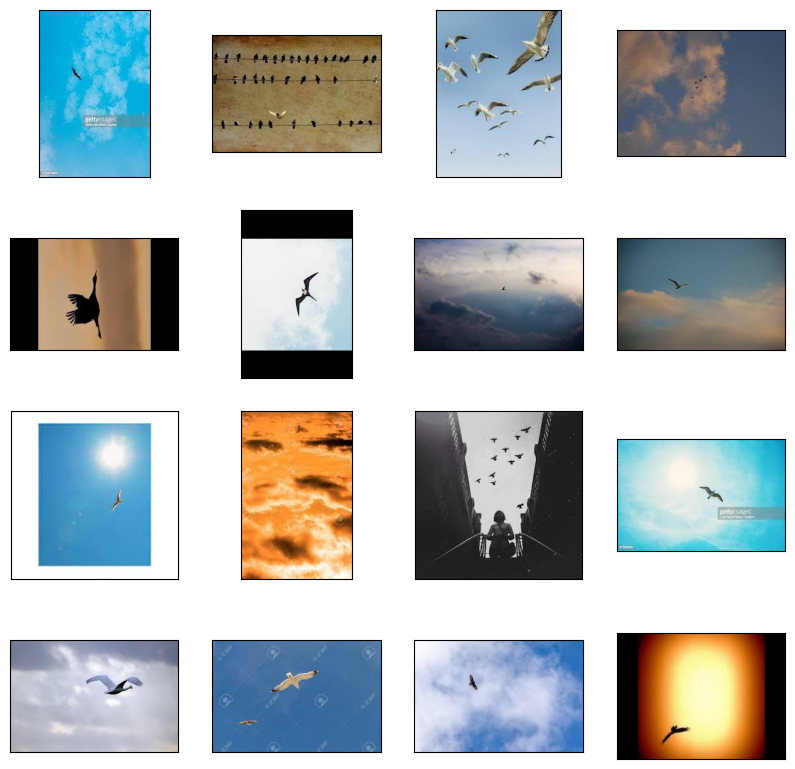

In [16]:
getImages(os.path.join(trainDirectory, "bird"), 16, SEED)

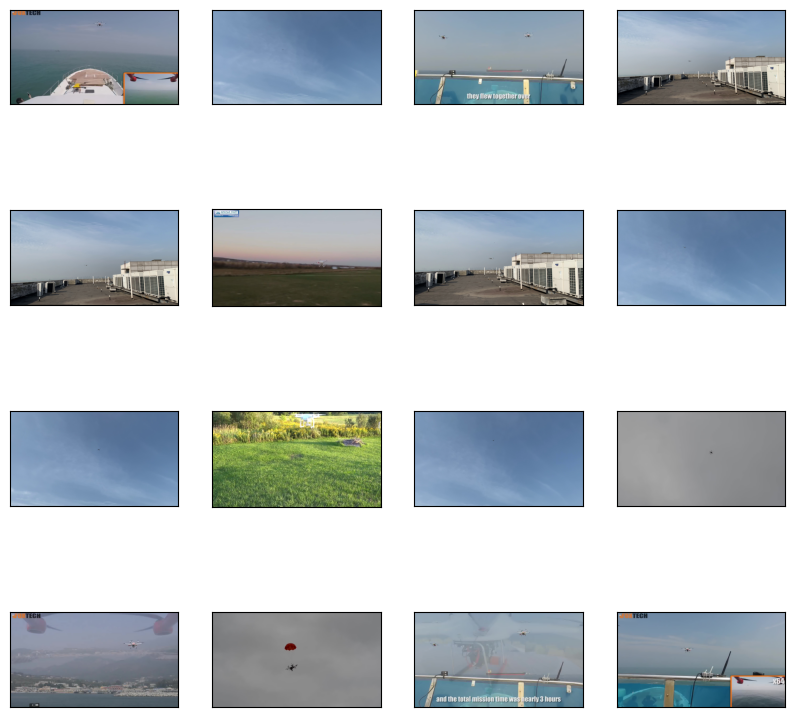

In [17]:
getImages(os.path.join(trainDirectory, "drone"), 16, SEED)

# Desbalanceo de clases y data augmentation
El dataset contiene más imágenes de drones que de aves, lo que puede derivar en que el modelo aprenda más a identificar drones que aves.
Para mitigar el desbalanceo de clases, se consideró una técnica de oversampling sobre la clase minoritaria, seguido de data augmentation a todas las clases, siguiendo enfoques similares a los propuestos por Guerrero et al. (2024), donde la aumentación dirigida permitió reducir el sesgo hacia las clases mayoritarias en tareas de clasificación de imágenes.
Es importante destacar que estas alteraciones en el dataset se hacen únicamente en el set de entrenamiento. Los set de validation y test se dejan como están.

Se realizó un oversampling aleatorio. Se calcularon las imágenes faltantes, seleccionando la misma cantidad aleatoriamente y duplicando cada imagen una vez.

In [18]:
def oversample(directory, minorClass, mayorClass, seed=42):
  """
  Selects images randomly and copies in the same directory

  Parameters
  ----------
  directory : str
    Path to the directory that contains the train set
  minorClass : str
    Minority class foldername
  mayorClass : str
    Mayority class foldername
  seed : int
    Random seed

  Returns
  -------
  None
  """

  mayorClassPath = os.path.join(directory, mayorClass)
  minorClassPath = os.path.join(directory, minorClass)

  mayorImages = sorted([i for i in os.listdir(mayorClassPath) if os.path.isfile(os.path.join(mayorClassPath, i))])
  minorImages = sorted([i for i in os.listdir(minorClassPath) if os.path.isfile(os.path.join(minorClassPath, i))])

  lenMayorImages = len(mayorImages)
  lenMinorImages = len(minorImages)
  imagesNeeded = lenMayorImages - lenMinorImages

  print(f"{mayorClass}: {lenMayorImages}")
  print(f"{minorClass}: {lenMinorImages}")
  print(f"Need to generate: {imagesNeeded}")

  if mayorImages == []:
    print(f"{mayorImages} has no images.")
    return

  if minorImages == []:
    print(f"{minorClassPath} has no images.")
    return

  if imagesNeeded <= 0:
    print(f"Dataset already balanced.")
    return

  np.random.seed(seed)
  selectedImages = np.random.choice(minorImages, size=imagesNeeded, replace=True)

  for index, image in enumerate(selectedImages):
    sourcePath = os.path.join(minorClassPath, image)
    filename, extension = os.path.splitext(image)
    newFileName = f"{filename}_copy_{index}{extension}"
    destinationPath = os.path.join(minorClassPath, newFileName)
    shutil.copy2(sourcePath, destinationPath)
  print(f"Generated {imagesNeeded} oversampled images in {minorClassPath}")


In [19]:
oversample(trainDirectory, 'bird', 'drone', seed=SEED)

drone: 1749
bird: 1124
Need to generate: 625
Generated 625 oversampled images in /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone/train/bird


Verificamos que se haya hecho el oversampling en train

In [20]:
countImages(outputDirectory, directoriesWithImages)

Images in train:
bird: 1749
drone: 1749
Images in test:
bird: 242
drone: 376
Images in val:
bird: 241
drone: 374


# Data augmentation
Después de aplicar oversampling, se usa ImageDataGenerator para generar imagenes nuevas en el ram mientras se entrena para no desperdiciar espacio. Un problema de tamaño limitado de se presentó a los autores Rares Ilie Orzan et al (2024) donde contaban con una cantidad limitada de imágenes (106) para su estudio. Aplicaron una serie de transformaciones a las imágenes para combatir la falta de datos.

In [21]:
# Constants
IMAGEWIDTH = 224
IMAGEHEIGHT = 224
BATCHSIZE = 16
ROTATIONRANGE = 30
TRANSLATIONS = 0.1
SCALING = [0.9, 1.1]
EPOCHS = 14

In [22]:
trainDatagen = ImageDataGenerator(
    rescale = 1.0/255,
    rotation_range = ROTATIONRANGE,
    width_shift_range = TRANSLATIONS,
    height_shift_range = TRANSLATIONS,
    zoom_range = SCALING,
    horizontal_flip = True,
    vertical_flip = False)

Para ello se asigna una fuente base de imágenes a modificar, se toman sólo las del directorio de train. En este caso sólo se toma una imagen y se muestra como se generarían 5 imágenes diferentes.

Found 3495 images belonging to 2 classes.


<Figure size 640x480 with 0 Axes>

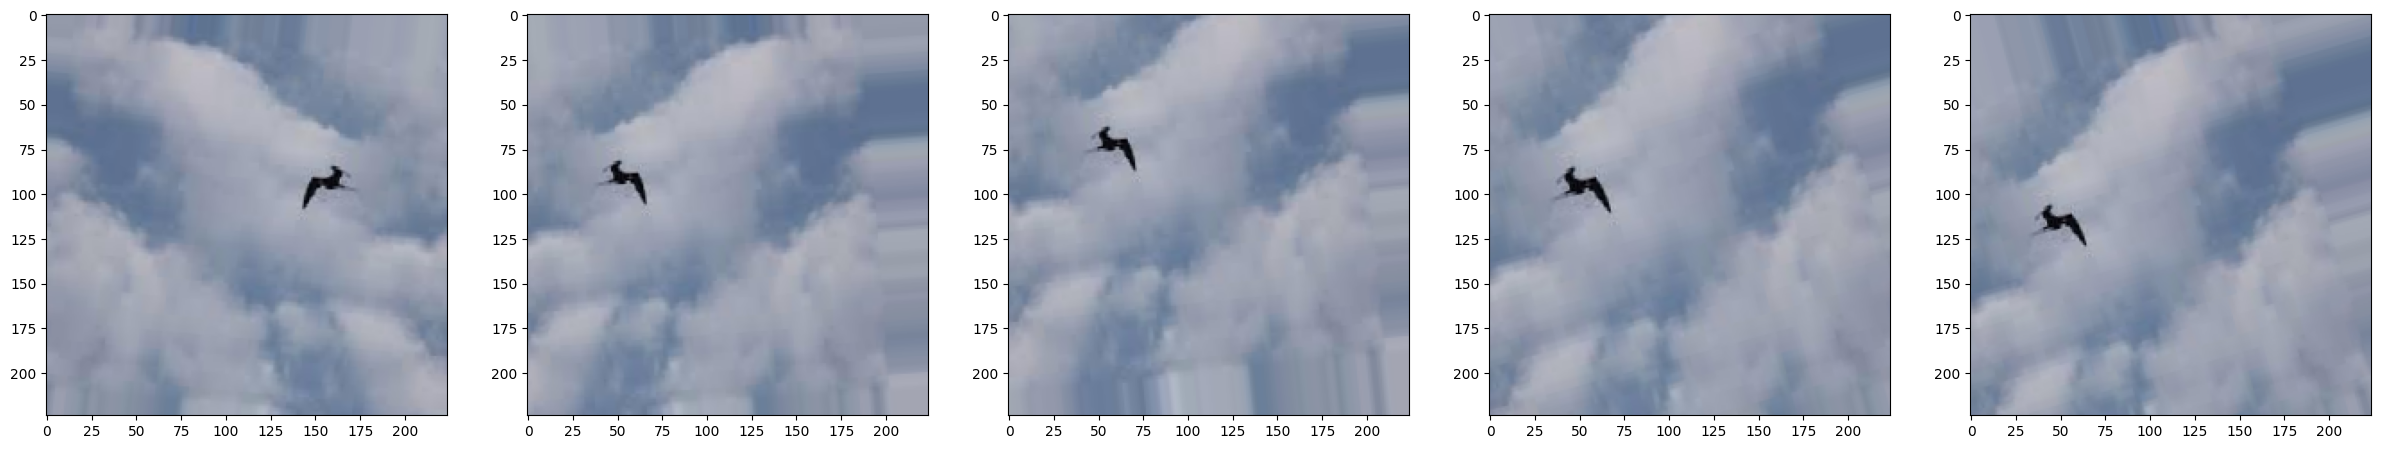

In [23]:
trainGenerator = trainDatagen.flow_from_directory(
    trainDirectory,
    target_size = (IMAGEWIDTH, IMAGEHEIGHT),
    batch_size = BATCHSIZE, # Images that the models gets in each iteration
    class_mode = "binary") # Has to be the same on the last neuron of the model

plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, 5, figsize=(30, 8))

for i in range(5) :
  axarr[i].imshow(trainGenerator[0][0][0])

(16, 224, 224, 3)
[0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0.]


<Figure size 640x480 with 0 Axes>

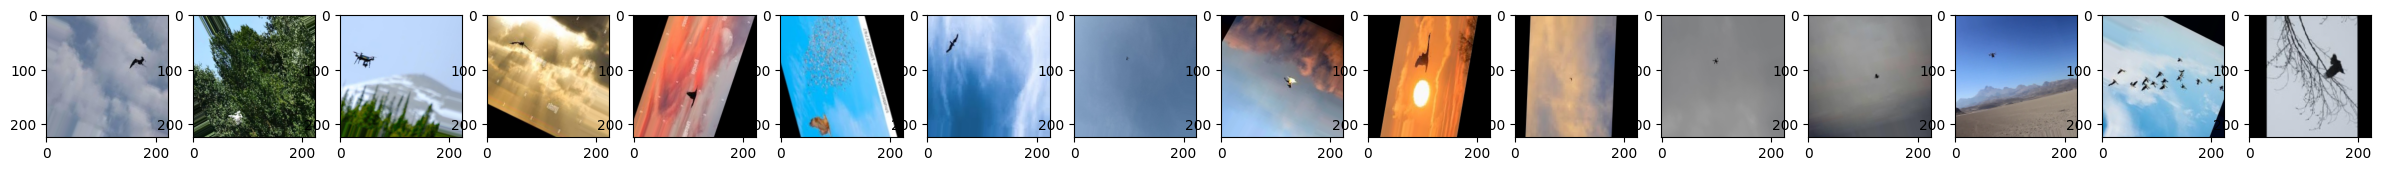

In [25]:
images , labels = trainGenerator[0]

print(images.shape)
print(labels)

plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 6))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

# Primera Red Neuronal Convolutiva (CNN)
Se crea la red neuronal convolutiva. Con la capa convolutiva se convierten las características de dos dimensiones (las imágenes) en matrices con las características más singnificativas. Posteriormente se convierte en un vector de una dimensión.

Este modelo se hizo basado en la documentación de tensorflow. Las dimensiones de ancho y alto tienden a reducirse a medida que se profundiza en la red. El número de canales de salida para cada capa Conv2D está controlado por el primer argumento.

In [26]:
def getModelCompiled():
  """
  Creates the model and compiles it

  Parameters
  ----------
  None

  Returns
  -------
  model : keras.models.Sequential
    Compiled model
  """
  model = models.Sequential()
  model.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape = (IMAGEWIDTH,IMAGEHEIGHT,3)))
  model.add(layers.MaxPooling2D((2, 2)))
  model.add(layers.Conv2D(64, (3, 3), activation="relu", input_shape = (IMAGEWIDTH,IMAGEHEIGHT,3)))
  model.add(layers.MaxPooling2D((2, 2)))
  model.add(layers.Conv2D(128, (3, 3), activation="relu", input_shape = (IMAGEWIDTH,IMAGEHEIGHT,3)))
  model.add(layers.MaxPooling2D((2, 2)))
  model.add(layers.Flatten())
  model.add(layers.Dense(128,activation="relu"))
  model.add(layers.Dense(1,activation="sigmoid"))

  model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"])

  return model

In [27]:
ThreeLayerCNN = getModelCompiled()
ThreeLayerCNN.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
%cd {parentDirectory}

/content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual


In [33]:
%ls

AviDetectClassifier.ipynb  BirdVSDrone/


In [34]:
!mkdir "checkpoints"

In [38]:
checkpointDirectory = os.path.join(parentDirectory, "checkpoints")
checkpointPath = os.path.join(checkpointDirectory, "ThreeLayerCNN", "checkpoint.weights.h5")
checkpoint = ModelCheckpoint(
    filepath = checkpointPath,
    save_weights_only = True,
    save_freq = "epoch",
    monitor = "val_accuracy",
    save_best_only=True,
    verbose = 1)

In [28]:
history = ThreeLayerCNN.fit(trainGenerator, epochs = EPOCHS)

Epoch 1/14
219/219 ━━━━━━━━━━━━━━━━━━━━ 106s 452ms/step - accuracy: 0.7213 - loss: 0.5512
Epoch 2/14
219/219 ━━━━━━━━━━━━━━━━━━━━ 92s 419ms/step - accuracy: 0.7963 - loss: 0.4372
Epoch 3/14
219/219 ━━━━━━━━━━━━━━━━━━━━ 92s 418ms/step - accuracy: 0.8278 - loss: 0.3844
Epoch 4/14
219/219 ━━━━━━━━━━━━━━━━━━━━ 88s 404ms/step - accuracy: 0.8289 - loss: 0.3734
Epoch 5/14
219/219 ━━━━━━━━━━━━━━━━━━━━ 89s 409ms/step - accuracy: 0.8609 - loss: 0.3175
Epoch 6/14
219/219 ━━━━━━━━━━━━━━━━━━━━ 89s 407ms/step - accuracy: 0.8552 - loss: 0.3304
Epoch 7/14
219/219 ━━━━━━━━━━━━━━━━━━━━ 93s 422ms/step - accuracy: 0.8787 - loss: 0.2786
Epoch 8/14
219/219 ━━━━━━━━━━━━━━━━━━━━ 91s 415ms/step - accuracy: 0.8873 - loss: 0.2697
Epoch 9/14
219/219 ━━━━━━━━━━━━━━━━━━━━ 90s 409ms/step - accuracy: 0.8735 - loss: 0.2889
Epoch 10/14
219/219 ━━━━━━━━━━━━━━━━━━━━ 91s 416ms/step - accuracy: 0.8933 - loss: 0.2448
Epoch 11/14
219/219 ━━━━━━━━━━━━━━━━━━━━ 90s 411ms/step - accuracy: 0.9127 - loss: 0.2082
Epoch 12/14
219/21

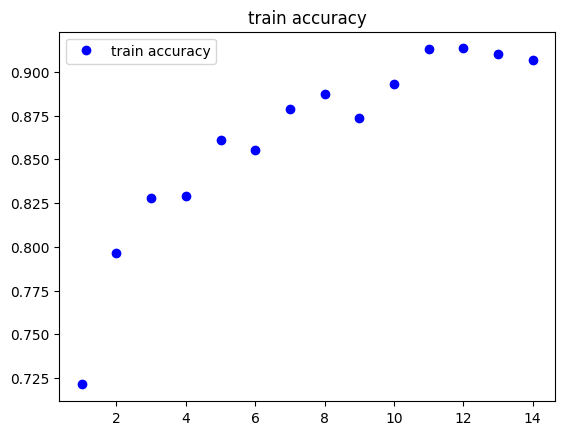

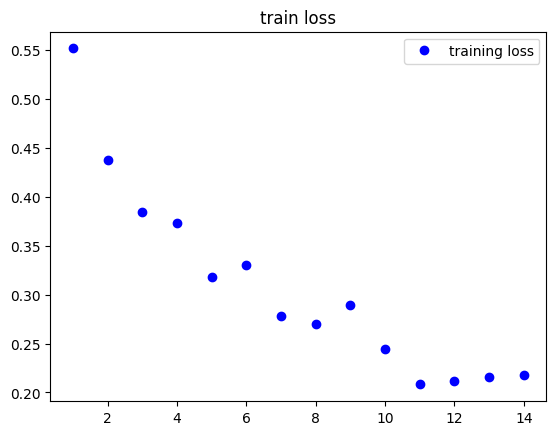

In [36]:
accuracy = history.history["accuracy"]
loss = history.history["loss"]

epochs = range(1, len(accuracy)+1)

plt.plot(epochs, accuracy, "bo", label="train accuracy")
plt.title("train accuracy")
plt.legend()

plt.figure()

plt.plot(epochs, loss, "bo", label ="training loss")
plt.title("train loss")
plt.legend()

plt.show()

In [42]:
# Inspect the checkpoint directory
! ls -lh {checkpointDirectory}

total 0


Con validation sólo se prueba con lo real, sin embargo, sí se escala. Ya que no se entrena, establecemos shuffle como False para comparar correctamente con las etiquetas reales y así evitar resultados caóticos o incorrectos

In [58]:
valDatagen = ImageDataGenerator(1.0/255)
valGenerator = valDatagen.flow_from_directory(
    valDirectory,
    target_size = (IMAGEWIDTH, IMAGEHEIGHT),
    batch_size = BATCHSIZE,
    class_mode = "binary",
    shuffle = False)

valLoss, valAccuracy = ThreeLayerCNN.evaluate(valGenerator)
print("\nval accuracy :\n", valAccuracy)

Found 615 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 331ms/step - accuracy: 0.6425 - loss: 244.5817

val accuracy :
 0.6424999833106995


Lo mismo aplica para el conjunto de test

In [59]:
testDatagen = ImageDataGenerator(1.0/255)
testGenerator = testDatagen.flow_from_directory(
    testDirectory,
    target_size = (IMAGEWIDTH, IMAGEHEIGHT),
    batch_size = BATCHSIZE,
    class_mode= "binary",
    shuffle = False)

testLoss, testAccuracy = ThreeLayerCNN.evaluate(testGenerator)
print("\ntest acc :\n", testAccuracy)

Found 618 images belonging to 2 classes.
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 255ms/step - accuracy: 0.6750 - loss: 259.3456

test acc :
 0.675000011920929


# Comparando resultados

El estado del arte en el problema de clasificación de aves y drones es un acuracy mayor al 90%.

In [74]:
def confusionMatrix(model, setGenerator):
  """
  Creates the confusion matrix based on real and predicted labels

  Parameters
  ----------
  model :
  setGenerator :

  Returns
  -------
  mat : np.ndarray
    Confusion matrix
  """
  predictions = model.predict(setGenerator)
  trueLabels = setGenerator.classes
  predictedClasses = (predictions > 0.5).astype(int).flatten()
  matrix = confusion_matrix(trueLabels, predictedClasses)

  print("\t\t", "label negative", "label positive")
  print("prediction negative\t", np.array(matrix[0][0]), "\t", np.array(matrix[0][1]))
  print("prediction positive\t", np.array(matrix[1][0]), "\t", np.array(matrix[1][1]))

  return matrix

def displayConfusionMatrix(confusionMatrix):
  """
  Displays the confusion matrix

  Parameters
  ----------
  confusionMatrix : np.ndarray
    Confusion matrix

  Returns
  -------
  None
  """
  display = ConfusionMatrixDisplay(
      confusion_matrix=confusionMatrix,
      display_labels=["Bird", "Drone"])
  display.plot()
  plt.title("Confusion matrix")
  plt.show()

def metrics(confusionMatrix):
  """
  Calculates the metrics based on the confusion matrix
  Accuracy, Precision, Recall and F1-score

  Parameters
  ----------
  confusionMatrix : np.ndarray
    Confusion matrix

  Returns
  -------
  None
  """
  truePositives = confusionMatrix[1][1]
  trueNegatives = confusionMatrix[0][0]
  falsePositives = confusionMatrix[0][1]
  falseNegatives = confusionMatrix[1][0]

  accuracy = (truePositives + trueNegatives) / (truePositives + trueNegatives + falsePositives + falseNegatives)
  precision = truePositives / (truePositives + falsePositives)
  recall = truePositives / (truePositives + falseNegatives)
  f1Score = (2 * (precision * recall)) / (precision + recall)

  print(f"Accuracy: {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"F1-score: {f1Score:.4f}")

## Primer modelo CNN

### Train

In [46]:
print("Model\t\t", "Train loss\t\t", "Train Accuracy\t")
print("Original\t", loss[-1:], "\t", accuracy[-1])

Model		 Train loss		 Train Accuracy	
Original	 [0.21772897243499756] 	 0.9067239165306091


In [60]:
confusionMatrixTrain = confusionMatrix(ThreeLayerCNN, trainGenerator)

219/219 ━━━━━━━━━━━━━━━━━━━━ 94s 430ms/step
		 label negative label positive
prediction negative	 843 	 903
prediction positive	 865 	 884


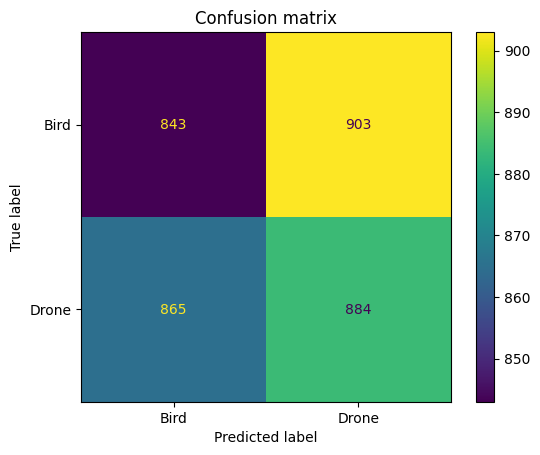

In [61]:
displayConfusionMatrix(confusionMatrixTrain)

In [75]:
metrics(confusionMatrixTrain)

Accuracy: 0.4941
Precision: 0.4947
Recall: 0.5054
F1-score: 0.5000


La metrica más baja es la precisión, algo esperado puesto que no acierta correctamente a la mayoría de las instancias de una clase, en este caso, bird. Es por esa razón que el recall es alto, ya que confunde mucho a la clase negativa. Como resultado, el F1-Score es muy bajo, al ser una media armónica de ambas métricas mencionadas, penaliza cuando una de las dos es baja.

### Validation

In [63]:
print("Model\t\t", "Val loss\t\t", "Val Accuracy\t")
print("Original\t", valLoss, "\t", valAccuracy)

Model		 Val loss		 Val Accuracy	
Original	 244.58168029785156 	 0.6424999833106995


In [64]:
confusionMatrixVal = confusionMatrix(ThreeLayerCNN, valGenerator)

/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 304ms/step
		 label negative label positive
prediction negative	 241 	 0
prediction positive	 299 	 75


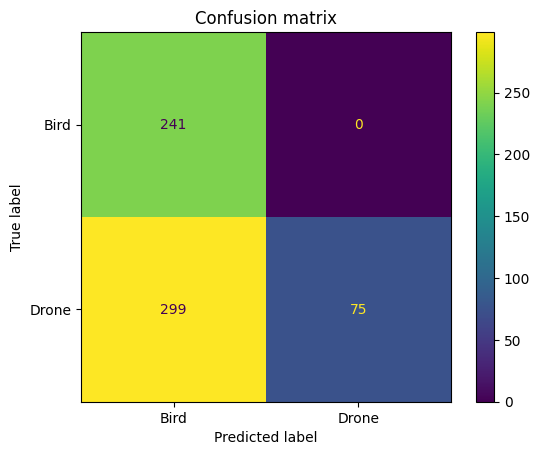

In [65]:
displayConfusionMatrix(confusionMatrixVal)

In [76]:
metrics(confusionMatrixVal)

Accuracy: 0.5138
Precision: 1.0000
Recall: 0.2005
F1-score: 0.3341


### Test

In [67]:
print("Model\t\t", "Test loss\t\t", "Test Accuracy\t")
print("Original\t", testLoss, "\t", testAccuracy)

Model		 Test loss		 Test Accuracy	
Original	 259.3455810546875 	 0.675000011920929


In [68]:
confusionMatrixTest = confusionMatrix(ThreeLayerCNN, testGenerator)

/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 304ms/step
		 label negative label positive
prediction negative	 242 	 0
prediction positive	 306 	 70


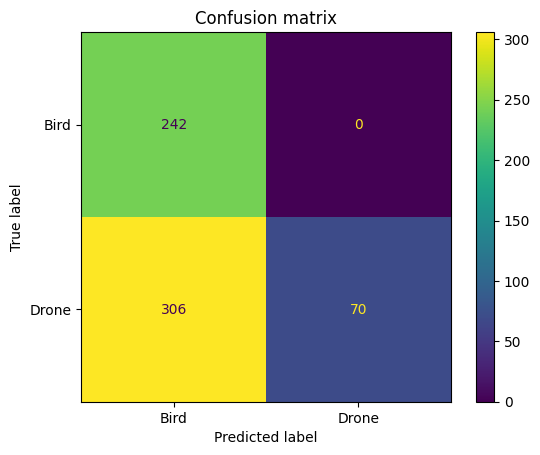

In [69]:
displayConfusionMatrix(confusionMatrixTest)

In [77]:
metrics(confusionMatrixTest)

Accuracy: 0.5049
Precision: 1.0000
Recall: 0.1862
F1-score: 0.3139


# Conclusiones y siguientes pasos
El modelo tuvo un desempeño deficiente en la tarea de clasificación entre aves y drones. Las métricas de evaluación empleadas muestran un comportamiento consistente entre los conjuntos de entrenamiento, validación y prueba con valores de accuracy del 50%, lo qe indica una capacidad limitada al discriminar entre ambas clases.

En el conjunto de entrenamiento se obtuvo una precisión, recall y F1-Score cercanos al 50%, lo que sugiere que el modelo no aprendió características suficientemente representativas para diferenciar entre ambas clases. Este comportamiento es similar a los conjuntos de validación y prueba.

En los conjuntos de validación y prueba no se registraron Falsos positivos, lo que llevó a una precisión del 100%. Sin embargo, el recall fue muy bajo, lo que significa que la mayoría de los drones fueron clasificados erróneamente como aves.

Estos resultados implican que el modelo detecta correctamente la clase bird pero no detecta una gran cantidad de instancias de la clase drone. En consecuencia, el valor de F1-score permanece bajo, lo que revela un equilibrio deficiente.

Los resultados evidencian un problema de subajuste, ya que el redimiento es similar en los tres conjuntos. El modelo presenta dificultades para aprender características que permitan separar adecuadamente ambas clases, es decir, su capacidad de generalización es insuficiente.

Comparándolo con el estado del arte en el problema de clasificación, el modelo actual no es lo suficientemente complejo para resolverlo.

Basado en estas observaciones, los siguientes pasos propuestos son incrementar la complejidad del modelo de forma que la dificultad del problema sea mejor tratada.